In [49]:
# ── Guarda de Dependencias ─────────────────────────────────────────
# Asegura que todos los paquetes requeridos estén instalados en el kernel activo.
# Es seguro re-ejecutar: pip omitirá los paquetes ya instalados.

import importlib, subprocess, sys

_REQUIRED = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'yfinance': 'yfinance',
    'bcchapi': 'bcchapi',
}

_missing = []
for _mod, _pip in _REQUIRED.items():
    try:
        importlib.import_module(_mod)
    except ModuleNotFoundError:
        _missing.append(_pip)

if _missing:
    print(f'Instalando paquetes faltantes: {_missing}')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet'] + _missing)
    print('Hecho. Paquetes instalados exitosamente.')
else:
    print('Todos los paquetes requeridos ya están instalados.')

Instalando paquetes faltantes: ['yfinance']
Hecho. Paquetes instalados exitosamente.


In [50]:
import bcchapi
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf

siete = bcchapi.Siete("luispino.2e@gmail.com", "Kirigami1@")

# Ejercicio 1 PIB real por región y actividad económica

Utilice la API de datos del Banco Central de Chile para obtener los datos del PIB 2025
(a precios del año anterior encadenado) por regiones, realice un gráfico de pie e interprete.
Luego, seleccione 2 regiones y para ellas muestre la desagregación por actividad económica
indicando cuáles son los principales aportes en cada una de esas regiones.

In [51]:
series_regiones = {
    "Región Metropolitana": "F035.PIB.FLU.R.CLP.2018.Z.Z.Z.13.0.T",
    "Región de Antofagasta": "F035.PIB.FLU.R.CLP.2018.Z.Z.Z.02.0.T",
    "Región de Valparaíso": "F035.PIB.FLU.R.CLP.2018.Z.Z.Z.05.0.T",
    "Región de Arica y Parinacota": "F035.PIB.FLU.R.CLP.2018.Z.Z.Z.15.0.T",
    "Región de Tarapacá": "F035.PIB.FLU.R.CLP.2018.Z.Z.Z.01.0.T",
    "Región de Coquimbo": "F035.PIB.FLU.R.CLP.2018.Z.Z.Z.04.0.T",
    "Región de Atacama": "F035.PIB.FLU.R.CLP.2018.Z.Z.Z.03.0.T",
    "Región de Libertador General Bernardo O'Higgins": "F035.PIB.FLU.R.CLP.2018.Z.Z.Z.06.0.T",
    "Región del Maule": "F035.PIB.FLU.R.CLP.2018.Z.Z.Z.07.0.T",
    "Región del Ñuble": "F035.PIB.FLU.R.CLP.2018.Z.Z.Z.16.0.T",
    "Región del Biobío": "F035.PIB.FLU.R.CLP.2018.Z.Z.Z.08.0.T",
    "Región de la Araucanía": "F035.PIB.FLU.R.CLP.2018.Z.Z.Z.09.0.T",
    "Región de los Ríos": "F035.PIB.FLU.R.CLP.2018.Z.Z.Z.14.0.T",
    "Región de los Lagos": "F035.PIB.FLU.R.CLP.2018.Z.Z.Z.10.0.T",
    "Región de Aysén del General Carlos Ibáñez del Campo": "F035.PIB.FLU.R.CLP.2018.Z.Z.Z.11.0.T",
    "Región de Magallanes y de la Antártica Chilena": "F035.PIB.FLU.R.CLP.2018.Z.Z.Z.12.0.T",
}

try:
    pib_2025 = siete.cuadro(
        series=[series_regiones[region] for region in series_regiones],
        nombres=[region for region in series_regiones],
        desde="2025-01-01",
        hasta="2025-12-31"
    )
    
    print("Datos del PIB 2025 descargados")
    
except Exception as e:
    print(f"Error: {e}")

Datos del PIB 2025 descargados


In [52]:
display(pib_2025)

,Región Metropolitana,Región de Antofagasta,Región de Valparaíso,Región de Arica y Parinacota,Región de Tarapacá,Región de Coquimbo,Región de Atacama,Región de Libertador General Bernardo O'Higgins,Región del Maule,Región del Ñuble,Región del Biobío,Región de la Araucanía,Región de los Ríos,Región de los Lagos,Región de Aysén del General Carlos Ibáñez del Campo,Región de Magallanes y de la Antártica Chilena
2025-01-01,21609.371743,4154.891438,3916.272356,408.311578,1101.235858,1612.529407,1099.019417,2399.905682,2197.016141,849.087156,3388.886488,1709.898717,720.584336,1868.023134,304.117584,544.076757
2025-04-01,21869.638788,4263.261369,3934.640569,410.327762,1234.779457,1637.088763,1110.215193,2042.702693,2112.174436,812.243706,3437.157821,1563.882948,727.987033,1923.277072,341.746120,514.720145
2025-07-01,21630.399431,4394.866057,3944.755736,417.302993,1219.204295,1588.164481,1158.901225,1771.352354,1729.598103,739.956438,3173.023048,1500.319917,681.496741,1792.828466,370.938584,515.658310


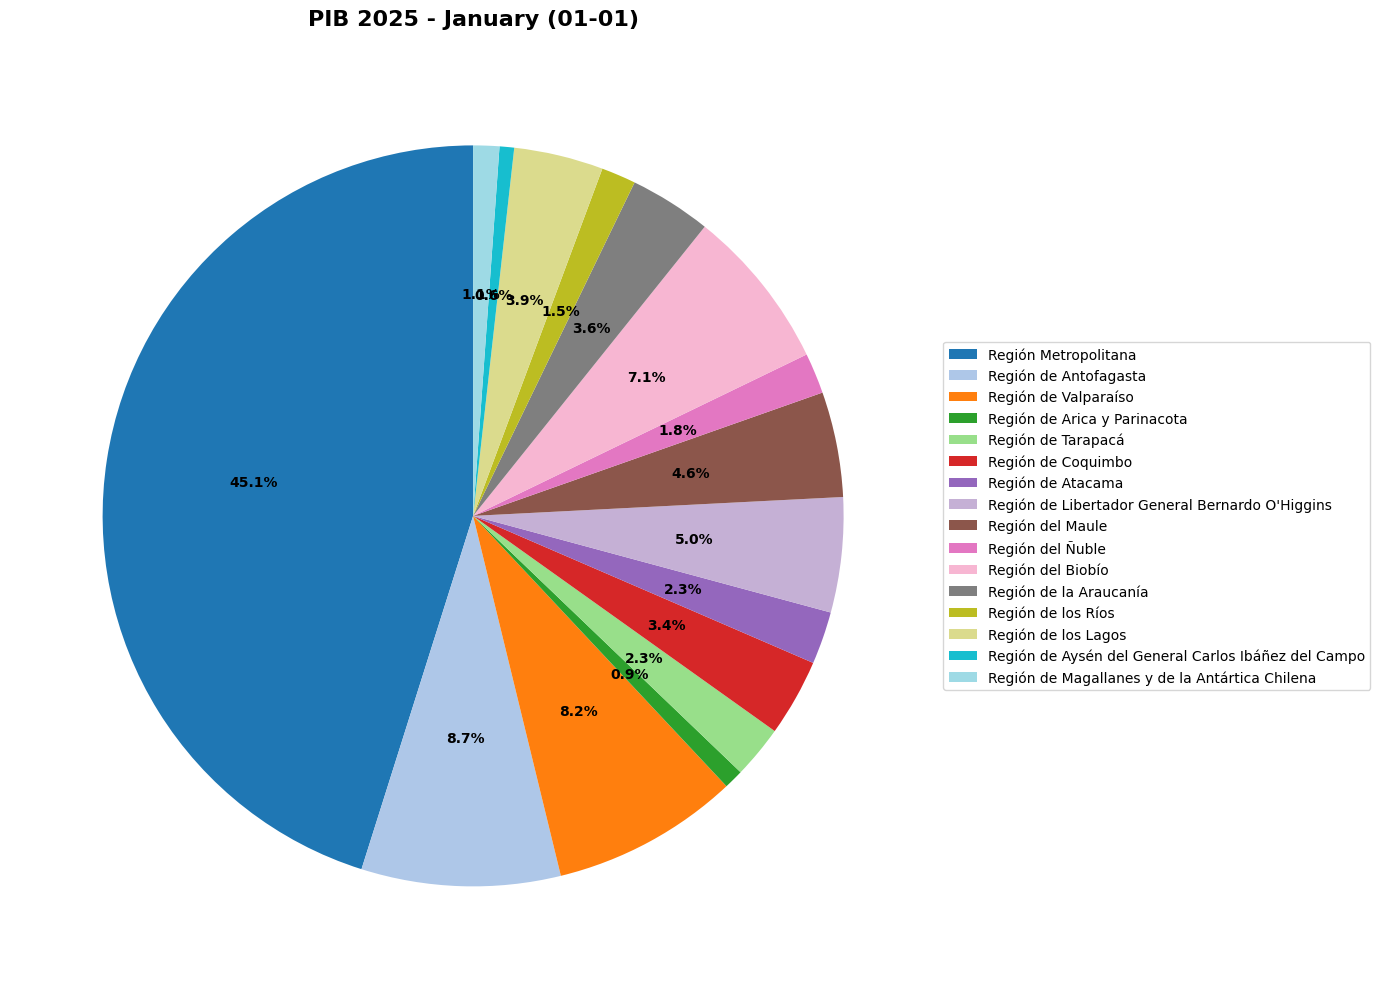

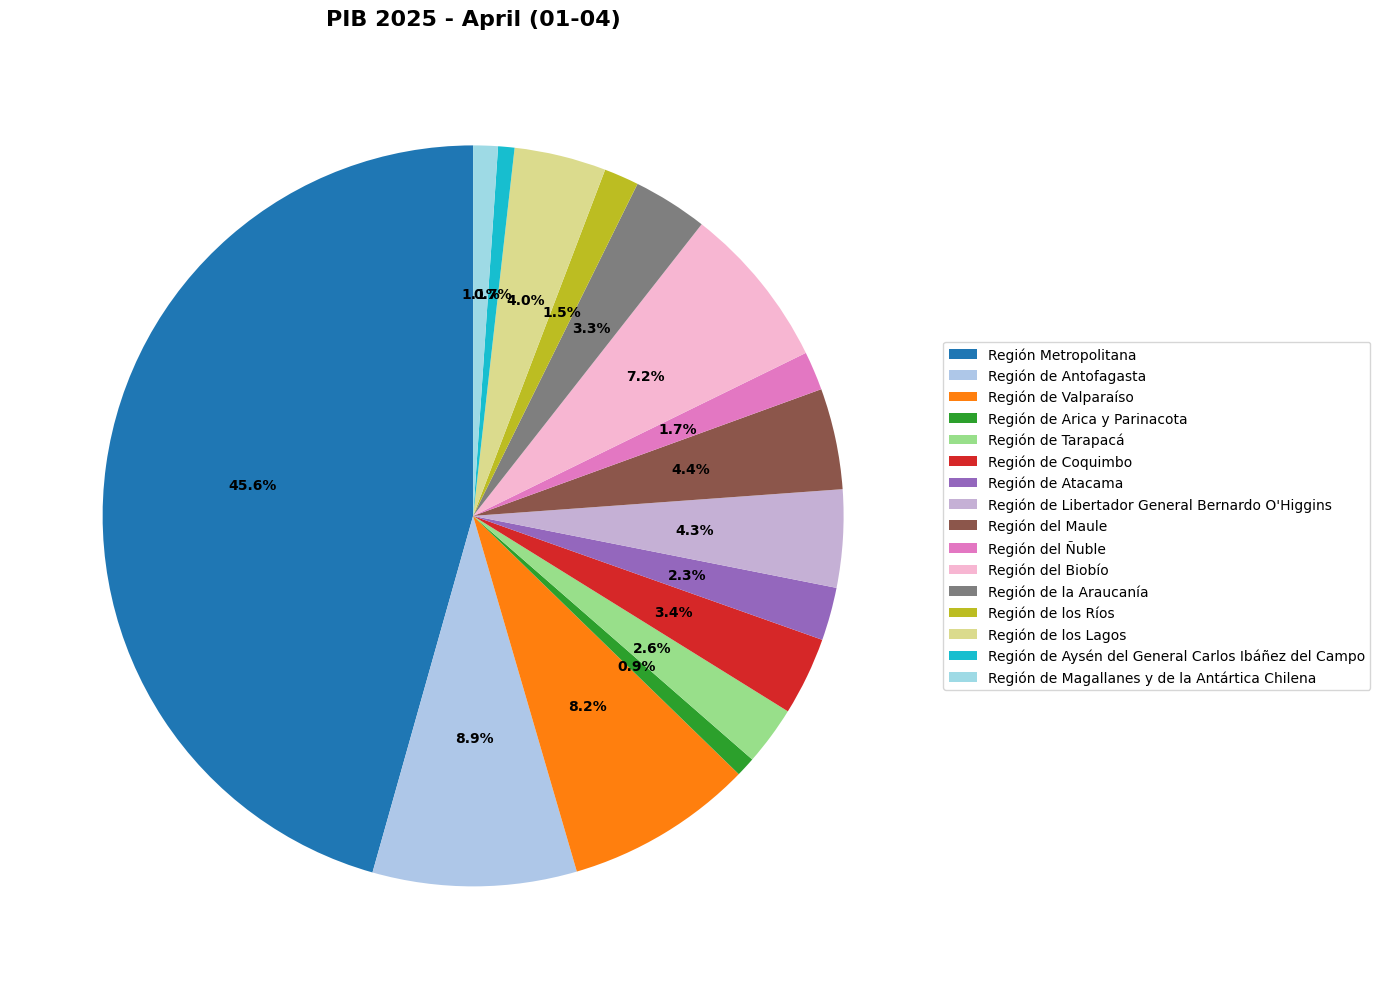

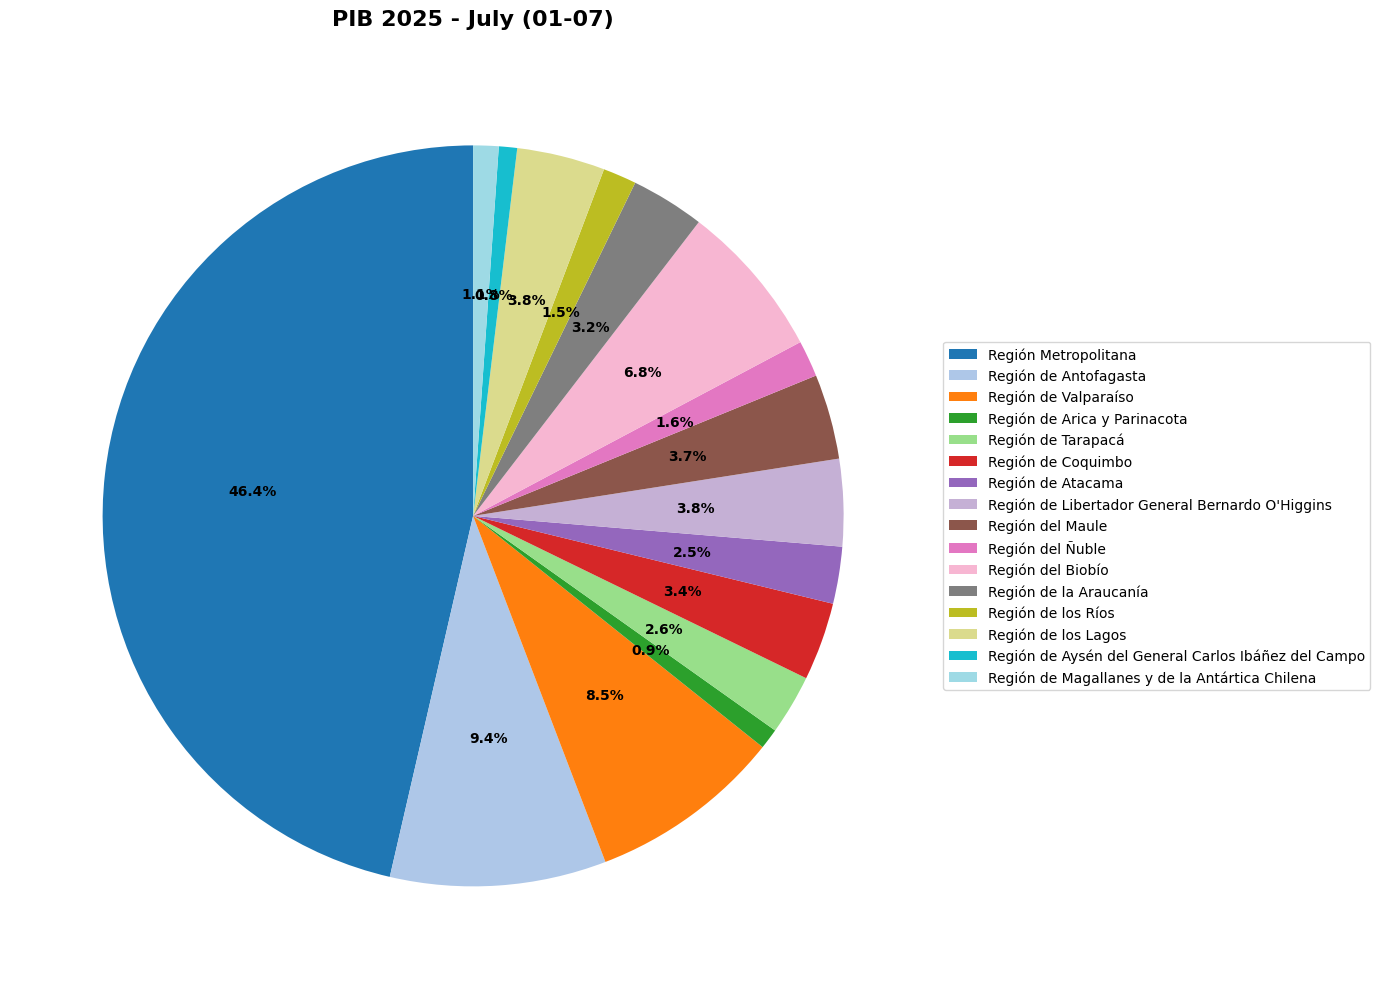

In [53]:
def graficar_pie_pib(serie, titulo):
    fig, ax = plt.subplots(figsize=(14, 10))
    colors = plt.cm.tab20(np.linspace(0, 1, len(serie)))
    ax.pie(
        serie.values,
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 10, 'weight': 'bold'},
        colors=colors
    )
    ax.set_title(titulo, fontsize=16, fontweight='bold', pad=20)
    ax.legend(serie.index, loc='center left', bbox_to_anchor=(1, 0, 0.5, 1), fontsize=10)
    plt.tight_layout()
    plt.show()

graficar_pie_pib(pib_2025.iloc[0], f'PIB 2025 - {pib_2025.index[0].strftime("%B (%d-%m)")}')
graficar_pie_pib(pib_2025.iloc[1], f'PIB 2025 - {pib_2025.index[1].strftime("%B (%d-%m)")}')
graficar_pie_pib(pib_2025.iloc[2], f'PIB 2025 - {pib_2025.index[2].strftime("%B (%d-%m)")}')

## Interpretación

**Concentración del PIB en la Región Metropolitana**
La Región Metropolitana cuenta con aproximadamente el 45-46% del PIB nacional. Esta cifra refleja la alta centralización económica alrededor de Santiago.

**Segundas regiones de importancia**
- **Región de Antofagasta** (8.7%-9.4%): Tuvo un ligero aumento de enero a julio.
- **Región de Valparaíso** (8.2%-8.5%): Su comportamiento es relativamente estable.

**Estabilidad Trimestral**
La distribución regional del PIB es muy estable, con variaciones menores de 0.5%. Esto sugiere que no hubo cambios estructurales significativos en la composición económica regional durante este período.

**Implicaciones económicas**
- La fuerte concentración en la Región Metropolitana implica dependencia económica de Santiago y sus alrededores.
- Las regiones del norte tienen participación relevante debido a que son sectores mineros.
- Muchas regiones del sur y centro muestran baja participación, lo que implica un bajo o menor desarrollo económico relativo, con excepción de regiones agrícolas e industriales.

# Ejercicio 2 PIB Nominal y real
A partir de la siguiente tabla calcule lo el PIB nominal y real (con base año 0) de cada
año, y calcule la tasa de crecimiento.

In [54]:
data = {
    'Año': [0,0,0,0, 1,1,1,1, 2,2,2,2],
    'Bien': ['Pan','Vino','Autos','Cobre']*3,
    'Cantidad': [2,3,2,4, 3,4,4,8, 5,3,3,9],
    'Precio': [3,5,10,7, 4,5,14,20, 5,7,16,22]
}

df = pd.DataFrame(data)
display(df)
precios_base = df[df['Año'] == 0][['Bien','Precio']].set_index('Bien')['Precio']

df['PIB_nominal'] = df['Cantidad'] * df['Precio'] 
df['Precio_base_año0'] = df['Bien'].map(precios_base)
df['PIB_real'] = df['Cantidad'] * df['Precio_base_año0']

resumen = df.groupby('Año')[['PIB_nominal','PIB_real']].sum()
resumen['Crecimiento_nominal(%)'] = resumen['PIB_nominal'].pct_change()*100 # pct_change() = Tasa de crecimiento (final-inicial)/inicial*100
resumen['Crecimiento_real(%)'] = resumen['PIB_real'].pct_change()*100
display(resumen)

,Año,Bien,Cantidad,Precio
0,0,Pan,2,3
1,0,Vino,3,5
2,0,Autos,2,10
3,0,Cobre,4,7
4,1,Pan,3,4
5,1,Vino,4,5
6,1,Autos,4,14
7,1,Cobre,8,20
8,2,Pan,5,5
9,2,Vino,3,7


,PIB_nominal,PIB_real,Crecimiento_nominal(%),Crecimiento_real(%)
Año,,,,
0,69,69,NaN,NaN
1,248,125,259.420290,81.15942
2,292,123,17.741935,-1.60000


Mientras el PIB nominal presenta un crecimiento considerable, el PIB real muestra un aumento mucho más pequeño e incluso se vuelve negativo en el año 2. Esta diferencia muestra la presencia de presiones inflacionarias dentro de la economía, ya que el crecimiento del PIB Nominal se explica principalmente por los aumentos de precios y no por un crecimiento en las cantidades producidas. En términos económicos, esto implica que el desempeño de la actividad productiva podría estar siendo menor del deseado. La caída del PIB real en el último período sugiere una posible desaceleración económica, lo cual podría traducirse en menores niveles de bienestar y un estancamiento productivo.

# Ejercicio 3 Canasta IPC
Realice un gráfico de pie con las 13 divisiones de la canasta IPC 2026, luego seleccione 2
de ellas y explique la incidencia que tuvieron en la inflación de febrero 2026 (Boletín IPC).

In [ ]:
# EXPLORACIÓN: Desagregación por ACTIVIDAD ECONÓMICA para una región
# Usamos la estrategia: primero exploramos UNA región, luego escalamos a otra

print("=" * 80)
print("EXPLORACIÓN: Desagregación por Actividad Económica")
print("=" * 80)

# Tomamos la PRIMERA región del diccionario como prueba
region_prueba = list(series_regiones.keys())[0]  # Región Metropolitana
codigo_region_prueba = series_regiones[region_prueba]

print(f"\nRegión seleccionada: {region_prueba}")
print(f"Código base: {codigo_region_prueba}")

# Buscamos series de actividades económicas que contengan el código de esta región
print(f"\nBuscando actividades económicas disponibles en la API para código: {codigo_region_prueba[:40]}...")

# Extraemos el número de región del código
# Ej: F035.PIB.FLU.R.CLP.2018.Z.Z.Z.13.0.T -> región 13 es Metropolitana
numero_region = codigo_region_prueba.split('.')[-3]
print(f"Número de región extraído: {numero_region}")

# Buscamos por actividades económicas
keywords_actividades_eco = ["actividad", "economica", "actividades", "sector"]
resultados_actividades = None

for keyword in keywords_actividades_eco:
    print(f"\nBuscando por: '{keyword}'")
    res = siete.buscar(keyword)
    print(f"  Encontrados: {len(res)} resultados")
    if len(res) > 0 and resultados_actividades is None:
        resultados_actividades = res
        print(f"  Guardando estos resultados para exploración") 

if resultados_actividades is not None:
    print(f"\nPrimeras 30 series de actividades económicas:")
    print(resultados_actividades.iloc[:30].to_string())
    
    # Ahora intentamos descargar datos de una actividad para ver estructura
    print("\n" + "=" * 80)
    print("INTENTANDO DESCARGAR UNA SERIE")
    print("=" * 80)
    
    for idx in range(min(10, len(resultados_actividades))):
        codigo = resultados_actividades.iloc[idx, 0]
        if isinstance(codigo, str) and '.' in codigo:
            print(f"\nIntentando: {codigo[:60]}")
            try:
                datos_actividad = siete.cuadro(
                    series=[codigo],
                    nombres=["actividad_prueba"],
                    desde="2025-01-01",
                    hasta="2025-12-31"
                )
                if not datos_actividad.empty:
                    print(f"✓ ÉXITO")
                    print(f"  Shape: {datos_actividad.shape}")
                    print(f"  Índice: {datos_actividad.index}")
                    print(f"  Datos:\n{datos_actividad}")
                    break
            except Exception as e:
                print(f"✗ Error: {str(e)[:60]}")
else:
    print("\nNo se encontraron series de actividades económicas")

EXPLORACIÓN: Desagregación por Actividad Económica

Región seleccionada: Región Metropolitana
Código base: F035.PIB.FLU.R.CLP.2018.Z.Z.Z.13.0.T

Buscando actividades económicas disponibles en la API para código: F035.PIB.FLU.R.CLP.2018.Z.Z.Z.13.0.T...
Número de región extraído: 13

Buscando por: 'actividad'
  Encontrados: 1266 resultados
  Guardando estos resultados para exploración

Buscando por: 'economica'
  Encontrados: 0 resultados

Buscando por: 'actividades'
  Encontrados: 599 resultados

Buscando por: 'sector'
  Encontrados: 2143 resultados

Primeras 30 series de actividades económicas:
                             seriesId frequencyCode                                                                                                                                                                                spanishTitle                                                                                                                                                               

# Ejercicio 4 Inflación
Considere una economía en la cual se tiene el siguiente detalle de los bienes producidos
o importados por sus habitantes.

In [60]:
data = {
    'Año': [0,0,0, 1,1,1],
    'Bien': ['Pan','Vino','Autos']*2,
    'Cantidad': [2,3,2, 3,4,4],
    'Precio': [3,5,10, 4,5,14]
}

df = pd.DataFrame(data)
display(df)

precios_base = df[df['Año']==0][['Bien','Precio']].set_index('Bien')['Precio']

df['Gasto'] = df['Precio'] * df['Cantidad']
df['Total_gasto'] = df.groupby('Año')['Gasto'].transform('sum')
df['theta'] = df['Gasto'] / df['Total_gasto']

# peso sobre el IPC
df['peso'] = df['Precio'] / df['Bien'].map(precios_base)

# IPC
df['IPC_term'] = df['theta'] * df['peso']

display(df)

ipc = df.groupby('Año')['IPC_term'].sum() * 100

print("IPC por año:")
print(ipc)

# Inflación
inflacion = ipc.pct_change() * 100
print("\nInflación:")
print(inflacion.iloc[1])  

,Año,Bien,Cantidad,Precio
0,0,Pan,2,3
1,0,Vino,3,5
2,0,Autos,2,10
3,1,Pan,3,4
4,1,Vino,4,5
5,1,Autos,4,14


,Año,Bien,Cantidad,Precio,Gasto,Total_gasto,theta,peso,IPC_term
0,0,Pan,2,3,6,41,0.146341,1.000000,0.146341
1,0,Vino,3,5,15,41,0.365854,1.000000,0.365854
2,0,Autos,2,10,20,41,0.487805,1.000000,0.487805
3,1,Pan,3,4,12,88,0.136364,1.333333,0.181818
4,1,Vino,4,5,20,88,0.227273,1.000000,0.227273
5,1,Autos,4,14,56,88,0.636364,1.400000,0.890909


IPC por año:
Año
0    100.0
1    130.0
Name: IPC_term, dtype: float64

Inflación:
29.999999999999982


EL calculo del ipc resulta en una inflación de aproximadamente 30%, lo que es un valor bastante alto en terminos de macroeconomia. Este resultado sedebe principalmente al incremento en el precio de los autos, un bien que además posee una alta ponderación dentro de la canasta de consumo. Esto nos muestra que la inflación no depende únicamente de la variación de precios (como vimos en el ejercicio 2), sino también del gasto de los consumidores, ya que aquellos bienes con mayor peso afectan de manera más significativa al IPC. Desde una perspectiva económica, una inflación de esta magnitud genera efectos adversos importantes, como la pérdida del poder adquisitivo y un aumento en la incertidumbre. Del mismo modo, este escenario podría motivar la implementación de politicas monetarias contractivas por parte del banco central, como el aumento de tasas de interés, con el objetivo de contener las presiones inflacionarias.

# Ejercicio 5 Mercado del dinero
Obtenga, a través de la API de yfinance, el tipo de cambio CLP/USD de los últimos 5
años. Junto con esto, obtenga la TPM de la API del banco central. Obtenga la correlación
y grafique ambos. A partir de esto interprete y explique la relación entre las dos.

In [64]:
start = "2021-01-01"
end = "2026-01-01"

# Tipo de cambio
clp = yf.download("CLP=X", start=start, end=end)

# Precio del cobre
cobre = yf.download("HG=F", start=start, end=end)

# ultimos precios
clp = clp['Close']
cobre = cobre['Close']

df = pd.concat([clp, cobre], axis=1)
df.columns = ['CLP_USD', 'Cobre']
df = df.dropna()
display(df)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_68330/2189897451.py:14: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df = pd.concat([clp, cobre], axis=1)


,CLP_USD,Cobre
Date,,
2021-01-04,710.000000,3.5530
2021-01-05,703.799988,3.6405
2021-01-06,695.400024,3.6500
2021-01-07,696.000000,3.6955
2021-01-08,712.299988,3.6735
...,...,...
2025-12-24,907.320007,5.4985
2025-12-26,903.849976,5.7665
2025-12-29,905.400024,5.4905


# Ejercicio 6 Oferta, demanda y tipo de cambio
Considere el mercado cambiario entre el Peso Chileno (CLP) y el Dólar Estadounidense
(USD), donde el precio de equilibrio es el tipo de cambio E (CLP/USD).

## 1. Equilibrio Inicial
Supongamos que las funciones de demanda y oferta de pesos en el mercado internacional
son lineales y dependen del tipo de cambio:

Demanda de CLP ($M_d$): Representa a los agentes que desean adquirir pesos.

$$M_d = 1200 - 40E$$

Oferta de CLP ($M_s$): Representa la masa monetaria dispuesta por el Banco Central.

$$M_s = 400 + 40E$$

Calcule el equilibrio, grafique e interprete sus resultados.

## 2. Escenario de Políticas Simultáneas
Se presentan dos choques macroeconómicos externos e internos:

### 2.1. Política Expansiva en EE.UU. (Emisión):
La Reserva Federal aumenta la oferta de dólares. Esto genera una abundancia de divisas extranjeras, lo que presiona al dólar a la baja (devaluación del USD). En nuestro modelo, esto se traduce en un aumento de la demanda de Pesos Chilenos por arbitraje.

$$M_d' = 1400 - 40E$$

### 2.2. Política Contractiva en Chile (Tasa de Interés):
El Banco Central de Chile aumenta la TPM para controlar la inflación. Esto reduce la oferta monetaria y atrae capitales financieros hacia el peso (apreciación del CLP).

$$M_s' = 200 + 40E$$

A partir de esto, calcule el nuevo equilibrio, grafique e interprete sus resultados.

Equilibrio inicial:
Tipo de cambio(E): 10.0
Cantidad de CLP: 800.0


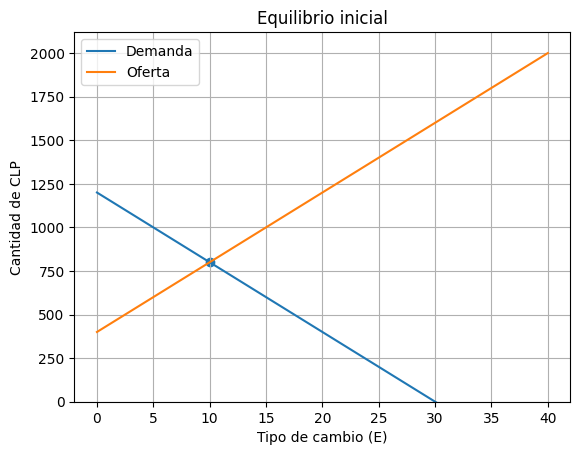


Nuevo equilibrio:
Tipo de cambio(E): 15.0
Cantidad de CLP: 800.0


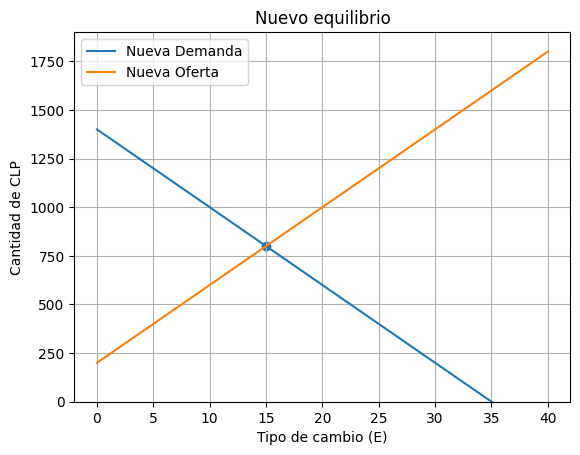

In [57]:
import numpy as np
import matplotlib.pyplot as plt

E = np.linspace(0, 40, 100)
Md = 1200 - 40*E
Ms = 400 + 40*E

# Equilibrio
E_eq = (1200 - 400) / (80) # despeje de la igualdad para encontrar el equilibrio (E)
Ms_eq = 400 + 40*E_eq # reemplazando E en la oferta para encontrar la cantidad de CLP

print("Equilibrio inicial:")
print("Tipo de cambio(E):", E_eq)
print("Cantidad de CLP:", Ms_eq)

plt.figure()
plt.plot(E, Md, label='Demanda')
plt.plot(E, Ms, label='Oferta')
plt.scatter(E_eq, Ms_eq)
plt.title("Equilibrio inicial")
plt.xlabel("Tipo de cambio (E)")
plt.ylabel("Cantidad de CLP")
plt.legend()
plt.grid()
plt.ylim(0, None)
plt.show()

# Nuevo equilibrio
Md2 = 1400 - 40*E
Ms2 = 200 + 40*E

E_eq2 = (1400 - 200) / (80)
Ms_eq2 = 200 + 40*E_eq2

print("\nNuevo equilibrio:")
print("Tipo de cambio(E):", E_eq2)
print("Cantidad de CLP:", Ms_eq2)

# Gráfico
plt.figure()
plt.plot(E, Md2, label='Nueva Demanda')
plt.plot(E, Ms2, label='Nueva Oferta')
plt.scatter(E_eq2, Ms_eq2)
plt.title("Nuevo equilibrio")
plt.xlabel("Tipo de cambio (E)")
plt.ylabel("Cantidad de CLP")
plt.legend()
plt.grid()
plt.ylim(0, None)
plt.show()

Podemos observar un aumento en el tipo de cambio de equilibrio desde 10 a 15 CLP/USD, lo que implica una depreciación del peso chileno frente al dólar. Esto se explica debido a la  expansión monetaria en Estados Unidos y una política contractiva en Chile, el resultado una demostracion de como el equilibrio tipo de cambio se ve afectado tanto por factores tanto externos como internos. Por un lado, la mayor disponibilidad de dólares a nivel internacional aumenta la demanda de monedas extranjeras; por otro, el alza en la tasa de interés local reduce la liquidez interna y atrae capitales financieros, reforzando los flujos hacia la economía chilena. A pesar de que ambos efectos podrían interpretarse como favorables para el peso chileno, el resultado final muestra una depreciación, lo que sugiere que el impacto conjunto de estos shocks termina siento contraproducente. Este resultado pone en evidencia que el tipo de cambio está expuesto múltiples fuerzas que podrian tener efectos adversos en el. En términos económicos, una depreciación bajo este contexto puede generar efectos mixtos: por un lado, mejora la competitividad externa, pero por otro, encarece las importaciones y puede amplificar presiones inflacionarias.